# Vizzes

In [25]:
import os
import os.path as osp
if osp.split(os.getcwd())[-1] == 'notebooks':
    os.chdir('..')

os.getcwd()

'e:\\Edoardo\\Education\\SportDataCampus\\ScoutingAgent'

## Shots

In [26]:
# Cella 1 — Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mplsoccer import Pitch, FontManager
from mplsoccer import VerticalPitch, FontManager

In [27]:
# Cella 2 — Preparazione colonne gold + split gol / non-gol

def prepare_gold_shots_for_plot(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Da righe `gold_match_shot_event`: location_x/y, shot_xg, shot_is_goal.
    Ritorna (df_non_goal, df_goal) con colonne x, y, xg.
    """
    out = df.copy()

    if "x" not in out.columns:
        out["x"] = pd.to_numeric(out["location_x"], errors="coerce")
    if "y" not in out.columns:
        out["y"] = pd.to_numeric(out["location_y"], errors="coerce")
    if "xg" not in out.columns:
        out["xg"] = pd.to_numeric(out.get("shot_xg"), errors="coerce").fillna(0.0)
    else:
        out["xg"] = pd.to_numeric(out["xg"], errors="coerce").fillna(0.0)

    if "shot_is_goal" in out.columns:
        is_goal = out["shot_is_goal"].astype(bool)
    else:
        # fallback raro
        is_goal = out.get("shot_outcome", pd.Series("", index=out.index)).astype(str).str.contains(
            "goal", case=False, na=False
        )

    out = out.dropna(subset=["x", "y"])
    out["x"] = out["x"].clip(0, 100)
    out["y"] = out["y"].clip(0, 100)

    df_goals = out[is_goal].copy()
    df_non = out[~is_goal].copy()
    return df_non, df_goals

In [28]:
def plot_gold_shots_mpl_style(
    df_shots: pd.DataFrame,
    title: str,
    *,
    figsize=(12, 10),
    font_prop=None,
    pitch=None,
    edgecolors="#b94b75",
    xg_scale=1900,
    xg_offset=100,
):
    df_non, df_goals = prepare_gold_shots_for_plot(df_shots)

    if pitch is None:
        pitch = VerticalPitch(
            pitch_type="wyscout",
            pitch_length=100,
            pitch_width=100,
            half=True,
            pad_bottom=0.5,
            goal_type="box",
            goal_alpha=0.8,
        )

    fig, ax = pitch.draw(figsize=figsize)

    if not df_non.empty:
        pitch.scatter(
            df_non["x"],
            df_non["y"],
            s=(df_non["xg"] * xg_scale) + xg_offset,
            edgecolors=edgecolors,
            c="None",
            hatch="///",
            marker="o",
            ax=ax,
        )

    if not df_goals.empty:
        pitch.scatter(
            df_goals["x"],
            df_goals["y"],
            s=(df_goals["xg"] * xg_scale) + xg_offset,
            edgecolors=edgecolors,
            linewidths=0.6,
            c="white",
            marker="football",
            ax=ax,
        )

    ax.text(
        40,
        80,
        s=title,
        size=30,
        fontproperties=font_prop,
        color=pitch.line_color,
        va="center",
        ha="center",
    )

    plt.tight_layout()
    return fig, ax

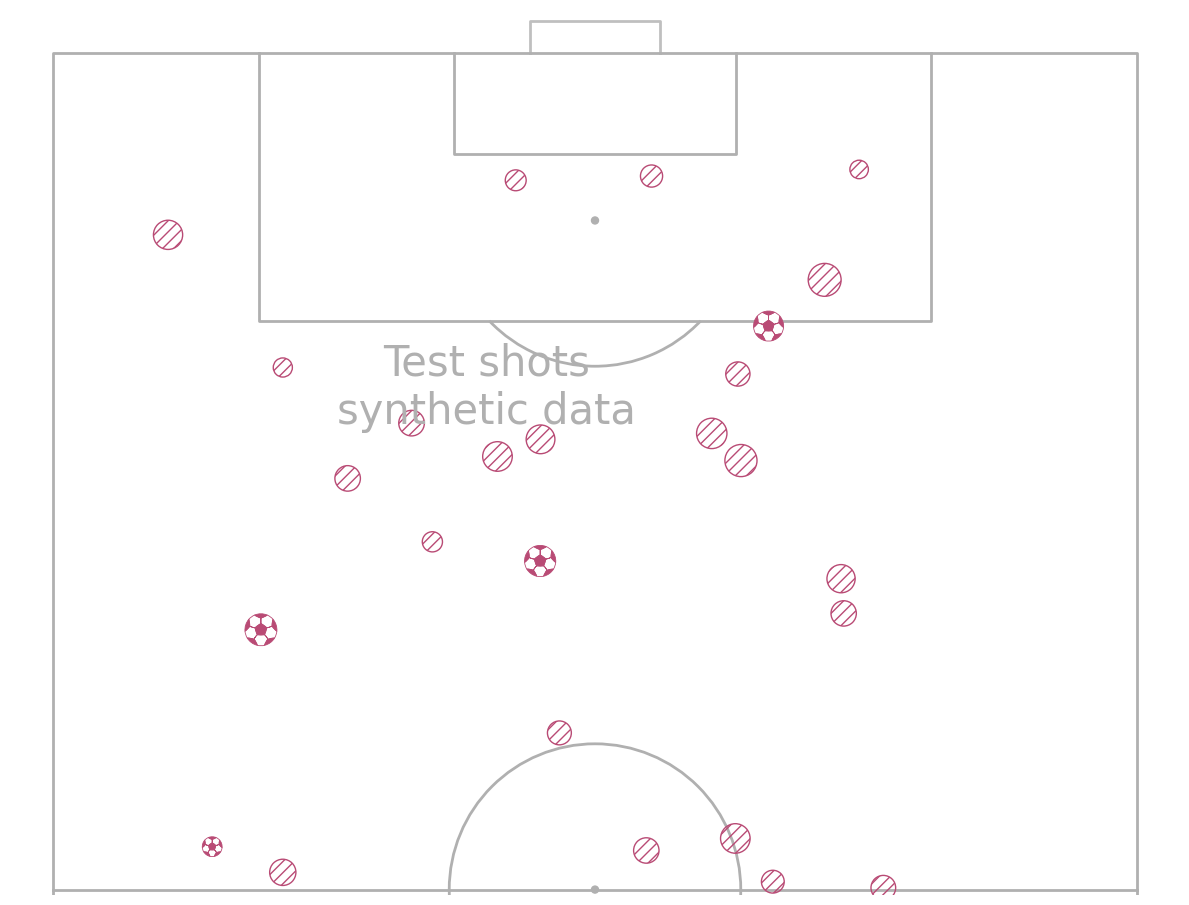

In [29]:
# Cella 5 — Test sintetico (senza BigQuery)

rng = np.random.default_rng(42)
n = 40

df_test = pd.DataFrame(
    {
        "location_x": rng.uniform(15, 95, n),
        "location_y": rng.uniform(10, 90, n),
        "shot_xg": rng.uniform(0.02, 0.25, n),
        "shot_is_goal": rng.random(n) < 0.12,
        "team_id": 675,
        "match_id": 1,
    }
)

fig, ax = plot_gold_shots_mpl_style(
    df_test,
    "Test shots\nsynthetic data",
    
)
plt.show()

In [30]:
# Cella 1 — helper immagini (file locale, URL HTTP, data:image/...;base64,...)

import io
import base64
import requests
import numpy as np
from PIL import Image

def _img_from_any(source: str | None):
    if not source:
        return None

    source = source.strip()
    try:
        # data URL base64
        if source.startswith("data:image"):
            b64 = source.split(",", 1)[1]
            raw = base64.b64decode(b64)
            return np.array(Image.open(io.BytesIO(raw)).convert("RGBA"))

        # URL HTTP(S)
        if source.startswith("http://") or source.startswith("https://"):
            r = requests.get(source, timeout=15)
            r.raise_for_status()
            return np.array(Image.open(io.BytesIO(r.content)).convert("RGBA"))

        # path locale
        return np.array(Image.open(source).convert("RGBA"))
    except Exception:
        return None

In [143]:
def add_header_branding(
    fig,
    title: str,
    *,
    left_logo_path: str = "images/sport_data_campus.png",
    team_img_source: str | None = None,
    player_img_source: str | None = None,
    header_center_y: float = 1,  # asse comune titolo + immagini
    logo_w: float = 0.16,
    logo_h: float = 0.11,
    right_h: float = 0.10,
    right_w_single: float = 0.08,
    right_w_double: float = 0.07,
):
    fig.subplots_adjust(top=0.84)

    fig.text(
        0.5,
        header_center_y,
        title,
        ha="center",
        va="center",  # così il blocco (anche 2 righe) è centrato su header_center_y
        fontsize=28,
        fontweight="bold",
        color="#A8A9AD",
    )

    def _axes_centered(x0, w, h):
        bottom = header_center_y - h / 2
        return fig.add_axes([x0, bottom, w, h])

    left_img = _img_from_any(left_logo_path)
    if left_img is not None:
        ax_left = _axes_centered(0.03, logo_w, logo_h)
        ax_left.imshow(left_img)
        ax_left.axis("off")

    team_img = _img_from_any(team_img_source)
    player_img = _img_from_any(player_img_source)

    if player_img is not None and team_img is not None:
        ax_p = _axes_centered(0.83, right_w_double, right_h)
        ax_p.imshow(player_img)
        ax_p.axis("off")
        ax_t = _axes_centered(0.91, right_w_double, right_h)
        ax_t.imshow(team_img)
        ax_t.axis("off")
    elif player_img is not None:
        ax_p = _axes_centered(0.90, right_w_single, right_h)
        ax_p.imshow(player_img)
        ax_p.axis("off")
    elif team_img is not None:
        ax_t = _axes_centered(0.90, right_w_single, right_h)
        ax_t.imshow(team_img)
        ax_t.axis("off")

In [144]:
# Cella 3 — integrazione nella tua funzione di plot

def plot_gold_shots_mpl_style(
    df_shots: pd.DataFrame,
    title: str,
    *,
    left_logo_path="images/sport_data_campus.png",
    team_img_source=None,      # image_data_url team
    player_img_source=None,    # image_data_url player (opzionale)
    font_prop=None,
):
    df_non, df_goals = prepare_gold_shots_for_plot(df_shots)

    pitch = VerticalPitch(
        pitch_type="wyscout", pitch_length=100, pitch_width=100,
        half=True, pad_bottom=0.5, goal_type="box", goal_alpha=0.8
    )
    fig, ax = pitch.draw(figsize=(12, 10))

    if not df_non.empty:
        pitch.scatter(
            df_non["x"], df_non["y"],
            s=(df_non["xg"] * 1900) + 100,
            edgecolors="#b94b75", c="None", hatch="///", marker="o", ax=ax
        )

    if not df_goals.empty:
        pitch.scatter(
            df_goals["x"], df_goals["y"],
            s=(df_goals["xg"] * 1900) + 100,
            edgecolors="#b94b75", linewidths=0.6, c="white",
            marker="football", ax=ax
        )

    # header con titolo + immagini
    add_header_branding(
        fig,
        title=title,
        left_logo_path=left_logo_path,
        team_img_source=team_img_source,
        player_img_source=player_img_source,
    )

    return fig, ax
    

In [145]:
from __future__ import annotations

import os
from typing import Any

import pandas as pd
from google.cloud import bigquery


def fetch_player_shots_single_match(
    player_id: int,
    match_id: int,
    *,
    project_id: str | None = None,
    dataset: str = "scouting_agent",
) -> dict[str, Any]:
    """
    Tiri del giocatore in una partita + URL immagini (dim_player, dim_team via team_id del tiro).

    Returns:
        {
            "shots": DataFrame (solo colonne tiro, senza URL duplicati),
            "player_image_data_url": str | None,
            "team_image_data_url": str | None,
            "team_id": int | None,
        }
    """
    pid = project_id or os.environ.get("GCP_PROJECT_ID")
    if not pid:
        raise ValueError("Passa project_id= oppure imposta GCP_PROJECT_ID")

    client = bigquery.Client(project=pid)
    fq_shots = f"`{pid}.{dataset}.gold_match_shot_event`"
    fq_player = f"`{pid}.{dataset}.dim_player`"
    fq_team = f"`{pid}.{dataset}.dim_team`"

    sql = f"""
    WITH base AS (
      SELECT
        s.match_id,
        s.event_id,
        s.season_id,
        s.competition_id,
        s.match_period,
        s.minute,
        s.second,
        s.location_x,
        s.location_y,
        s.team_id,
        s.opponent_team_id,
        s.player_id,
        s.shot_is_goal,
        s.shot_xg,
        s.shot_outcome,
        s.shot_body_part,
        p.image_data_url AS player_image_data_url,
        t.image_data_url AS team_image_data_url
      FROM {fq_shots} AS s
      LEFT JOIN {fq_player} AS p ON s.player_id = p.player_id
      LEFT JOIN {fq_team} AS t ON s.team_id = t.team_id
      WHERE s.player_id = @player_id
        AND s.match_id = @match_id
    )
    SELECT * FROM base
    ORDER BY minute, second, event_id
    """
    job = client.query(
        sql,
        job_config=bigquery.QueryJobConfig(
            query_parameters=[
                bigquery.ScalarQueryParameter("player_id", "INT64", player_id),
                bigquery.ScalarQueryParameter("match_id", "INT64", match_id),
            ]
        ),
    )
    df = job.to_dataframe()
    if df.empty:
        return {
            "shots": df,
            "player_image_data_url": None,
            "team_image_data_url": None,
            "team_id": None,
        }

    player_url = df["player_image_data_url"].dropna().iloc[0] if "player_image_data_url" in df.columns else None
    team_url = df["team_image_data_url"].dropna().iloc[0] if "team_image_data_url" in df.columns else None
    tid = int(df["team_id"].iloc[0]) if pd.notna(df["team_id"].iloc[0]) else None

    shot_cols = [
        c
        for c in df.columns
        if c not in ("player_image_data_url", "team_image_data_url")
    ]
    return {
        "shots": df[shot_cols].copy(),
        "player_image_data_url": str(player_url) if player_url is not None and str(player_url).strip() else None,
        "team_image_data_url": str(team_url) if team_url is not None and str(team_url).strip() else None,
        "team_id": tid,
    }

{'shots':    match_id    event_id  season_id  competition_id match_period  minute  \
0   5718123  2921495597     191659             795           1H      16   

   second  location_x  location_y  team_id  opponent_team_id  player_id  \
0      18          87          49      679               687     722567   

   shot_is_goal  shot_xg     shot_outcome shot_body_part  
0         False  0.09287  miss_off_target  head_or_other  , 'player_image_data_url': 'https://cdn5.wyscout.com/photos/players/public/g-235322_100x130.png', 'team_image_data_url': 'https://cdn5.wyscout.com/photos/team/public/47_120x120.png', 'team_id': 679}


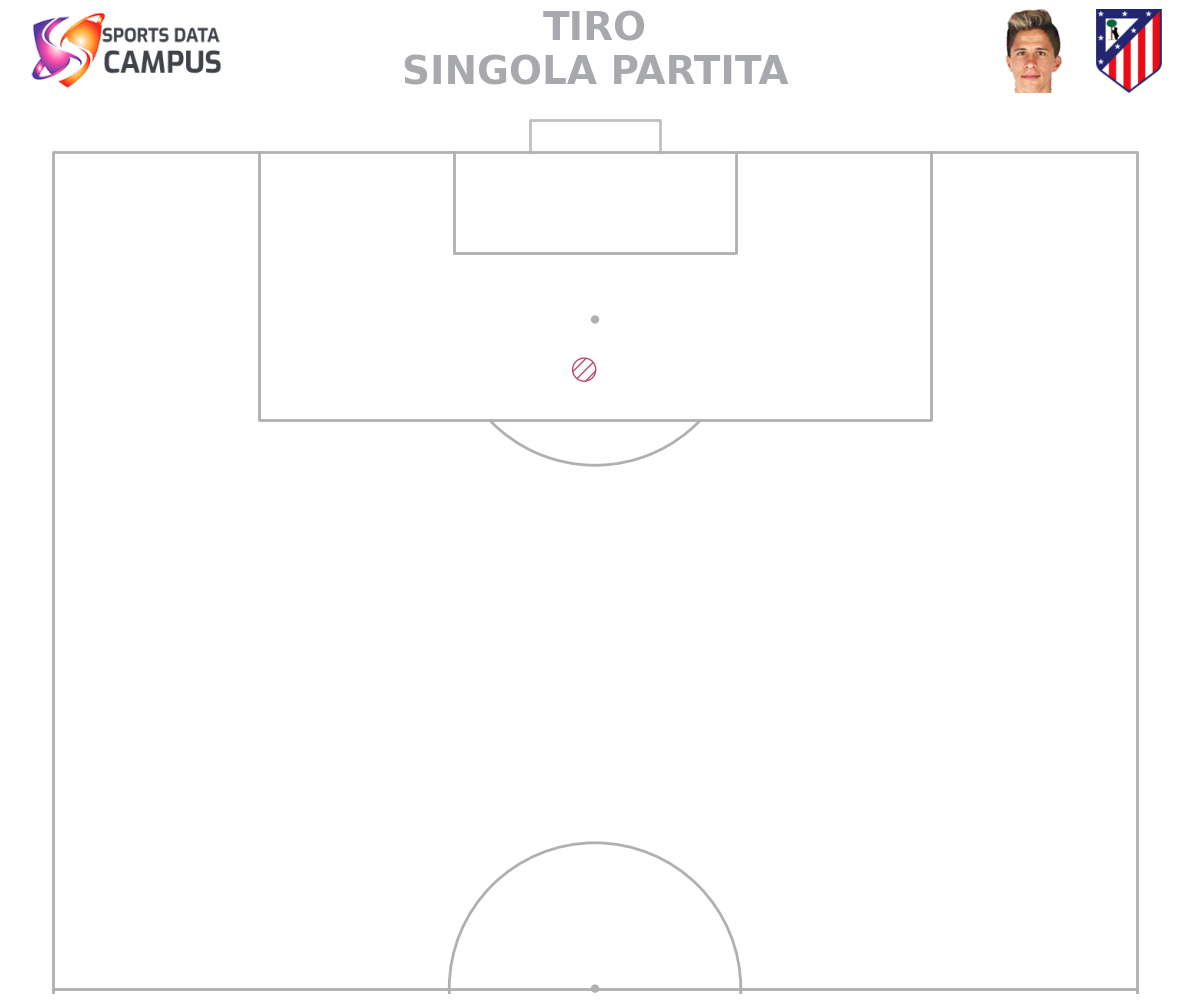

In [146]:
out = fetch_player_shots_single_match(player_id=722567, match_id=5718123)
print(out)
fig, ax = plot_gold_shots_mpl_style(
    out["shots"],
    title="TIRO\nSINGOLA PARTITA",
    player_img_source=out["player_image_data_url"],
    team_img_source=out["team_image_data_url"],
)

## Key Pass e Cross

In [59]:
from __future__ import annotations

from typing import Literal

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from mplsoccer import VerticalPitch


def _prepare_pass_leading_df(
    df: pd.DataFrame,
    *,
    x_col: str = "x",
    y_col: str = "y",
    end_x_col: str = "end_x",
    end_y_col: str = "end_y",
) -> pd.DataFrame:
    """Se usi gold Wyscout: location_x/y + pass_end_x/y -> x,y,end_x,end_y."""
    out = df.copy()
    mapping = {
        "location_x": "x",
        "location_y": "y",
        "pass_end_x": "end_x",
        "pass_end_y": "end_y",
    }
    for old, new in mapping.items():
        if new not in out.columns and old in out.columns:
            out[new] = out[old]

    need = [x_col, y_col, end_x_col, end_y_col]
    missing = [c for c in need if c not in out.columns]
    if missing:
        raise ValueError(f"Mancano colonne: {missing}. Passa rename o x_col=...")

    out[x_col] = pd.to_numeric(out[x_col], errors="coerce")
    out[y_col] = pd.to_numeric(out[y_col], errors="coerce")
    out[end_x_col] = pd.to_numeric(out[end_x_col], errors="coerce")
    out[end_y_col] = pd.to_numeric(out[end_y_col], errors="coerce")
    return out.dropna(subset=[x_col, y_col, end_x_col, end_y_col])


def plot_passes_leading_to_shots_grid(
    df_pass: pd.DataFrame,
    team1: str,
    team2: str,
    *,
    mask_goal: pd.Series | None = None,
    is_goal_col: str | None = None,
    x_col: str = "x",
    y_col: str = "y",
    end_x_col: str = "end_x",
    end_y_col: str = "end_y",
    pitch_coords: Literal["statsbomb", "wyscout_100"] = "statsbomb",
    endnote_text: str = "@your_twitter_handle",
    font_prop=None,
    line_label: str = "pass leading to shot",
    figheight: float = 12,
) -> tuple[plt.Figure, dict]:
    """
    Stile gallery mplsoccer (VerticalPitch + grid + comet + football marker).

    - mask_goal: Series bool stessa lunghezza di df (priorità su is_goal_col).
    - is_goal_col: es. colonna su df che indica gol sul tiro finale (bool).
    - pitch_coords:
        - 'statsbomb' -> pitch_type statsbomb (df in coordinate StatsBomb).
        - 'wyscout_100' -> custom 100x100 (tipico gold: location_* / pass_end_*).
    """
    d = _prepare_pass_leading_df(
        df_pass, x_col=x_col, y_col=y_col, end_x_col=end_x_col, end_y_col=end_y_col
    )
    if d.empty:
        raise ValueError("DataFrame pass vuoto dopo dropna.")

    if mask_goal is not None:
        mg = mask_goal.reindex(d.index).fillna(False).astype(bool)
    elif is_goal_col is not None and is_goal_col in d.columns:
        mg = d[is_goal_col].fillna(False).astype(bool)
    else:
        mg = pd.Series(False, index=d.index)

   
    pitch = VerticalPitch(
        pitch_type="wyscout",
        pitch_length=100,
        pitch_width=100,
        pitch_color="#22312b",
        line_color="#c7d5cc",
        half=True,
        pad_top=2,
    )

    fig, axs = pitch.grid(
        endnote_height=0.03,
        endnote_space=0,
        figheight=figheight,
        title_height=0.08,
        title_space=0,
        axis=False,
        grid_height=0.82,
    )
    fig.set_facecolor("#22312b")

    pitch.lines(
        d[x_col],
        d[y_col],
        d[end_x_col],
        d[end_y_col],
        lw=10,
        transparent=True,
        comet=True,
        cmap="jet",
        label=line_label,
        ax=axs["pitch"],
    )

    g = d[mg]
    ng = d[~mg]

    if not g.empty:
        pitch.scatter(
            g[end_x_col],
            g[end_y_col],
            s=700,
            marker="football",
            edgecolors="black",
            c="white",
            zorder=2,
            label="goal",
            ax=axs["pitch"],
        )
    if not ng.empty:
        pitch.scatter(
            ng[end_x_col],
            ng[end_y_col],
            edgecolors="white",
            c="#22312b",
            s=700,
            zorder=2,
            label="shot",
            ax=axs["pitch"],
        )

    kw = dict(fontsize=25, color="#dee6ea")
    if font_prop is not None:
        kw["fontproperties"] = font_prop

    axs["endnote"].text(1, 0.5, endnote_text, va="center", ha="right", **kw)

    axs["title"].text(
        0.5,
        0.5,
        f"{team1} passes leading to shots \n vs {team2}",
        va="center",
        ha="center",
        **kw,
    )

    legend = axs["pitch"].legend(
        facecolor="#22312b",
        edgecolor="None",
        loc="lower center",
        handlelength=4,
    )
    for text in legend.get_texts():
        if font_prop is not None:
            text.set_fontproperties(font_prop)
        text.set_fontsize(25)

    return fig, axs

In [60]:
from __future__ import annotations

import os
from typing import Literal

import pandas as pd
from google.cloud import bigquery


def fetch_key_passes_and_crosses(
    *,
    match_id: int | None = None,
    player_id: int | None = None,
    team_id: int | None = None,
    season_id: int | None = None,
    competition_id: int | None = None,
    event_type: Literal["both", "key_pass", "cross"] = "both",
    include_free_kick_cross: bool = True,
    include_shot_assist_as_key: bool = True,
    only_accurate: bool = False,
    limit: int = 5000,
    project_id: str | None = None,
    dataset: str = "scouting_agent",
) -> pd.DataFrame:
    """
    Recupera passaggi chiave e/o cross da gold_match_pass_event.
    Restituisce colonne utili per analisi/plot pass map.
    """
    pid = project_id or os.environ.get("GCP_PROJECT_ID")
    if not pid:
        raise ValueError("Passa project_id oppure imposta GCP_PROJECT_ID")

    if match_id is None and player_id is None and team_id is None and season_id is None and competition_id is None:
        raise ValueError("Specifica almeno un filtro (es. match_id o team_id o player_id).")

    if limit < 1:
        limit = 1
    if limit > 20000:
        limit = 20000

    table = f"`{pid}.{dataset}.gold_match_pass_event`"

    # Definizione filtro eventi
    if event_type == "key_pass":
        key_expr = "is_key_pass OR is_shot_assist" if include_shot_assist_as_key else "is_key_pass"
        event_filter = f"({key_expr})"
    elif event_type == "cross":
        cross_expr = "is_cross OR is_free_kick_cross" if include_free_kick_cross else "is_cross"
        event_filter = f"({cross_expr})"
    else:  # both
        key_expr = "is_key_pass OR is_shot_assist" if include_shot_assist_as_key else "is_key_pass"
        cross_expr = "is_cross OR is_free_kick_cross" if include_free_kick_cross else "is_cross"
        event_filter = f"(({key_expr}) OR ({cross_expr}))"

    sql = f"""
    SELECT
      match_id,
      event_id,
      season_id,
      competition_id,
      match_period,
      minute,
      second,
      team_id,
      opponent_team_id,
      player_id,
      recipient_player_id,
      location_x,
      location_y,
      pass_end_x,
      pass_end_y,
      pass_accurate,
      pass_length_m,
      pass_angle_deg,
      pass_height,
      is_key_pass,
      is_shot_assist,
      is_cross,
      is_free_kick_cross,
      is_progressive_pass,
      is_through_pass,
      is_pass_to_final_third,
      is_pass_to_penalty_area
    FROM {table}
    WHERE {event_filter}
      {"AND match_id = @match_id" if match_id is not None else ""}
      {"AND player_id = @player_id" if player_id is not None else ""}
      {"AND team_id = @team_id" if team_id is not None else ""}
      {"AND season_id = @season_id" if season_id is not None else ""}
      {"AND competition_id = @competition_id" if competition_id is not None else ""}
      {"AND pass_accurate IS TRUE" if only_accurate else ""}
    ORDER BY match_id, minute, second, event_id
    LIMIT @limit
    """

    params: list[bigquery.ScalarQueryParameter] = [
        bigquery.ScalarQueryParameter("limit", "INT64", int(limit))
    ]
    if match_id is not None:
        params.append(bigquery.ScalarQueryParameter("match_id", "INT64", int(match_id)))
    if player_id is not None:
        params.append(bigquery.ScalarQueryParameter("player_id", "INT64", int(player_id)))
    if team_id is not None:
        params.append(bigquery.ScalarQueryParameter("team_id", "INT64", int(team_id)))
    if season_id is not None:
        params.append(bigquery.ScalarQueryParameter("season_id", "INT64", int(season_id)))
    if competition_id is not None:
        params.append(bigquery.ScalarQueryParameter("competition_id", "INT64", int(competition_id)))

    client = bigquery.Client(project=pid)
    job = client.query(sql, job_config=bigquery.QueryJobConfig(query_parameters=params))
    return job.to_dataframe()

In [66]:
# 2) Solo key pass di un giocatore in una partita
df_pass = fetch_key_passes_and_crosses(
    player_id=722567, 
    match_id=5718123,
    include_shot_assist_as_key=True,
    only_accurate=False,
)
print(df_pass[["event_id", "minute", "second", "is_key_pass", "is_shot_assist"]].head())

     event_id  minute  second  is_key_pass  is_shot_assist
0  2921495407       3      45        False            True
1  2921495411       4      30        False            True
2  2921495472      10      41        False           False
3  2921495641      18      45        False           False
4  2921495895      29      22         True            True


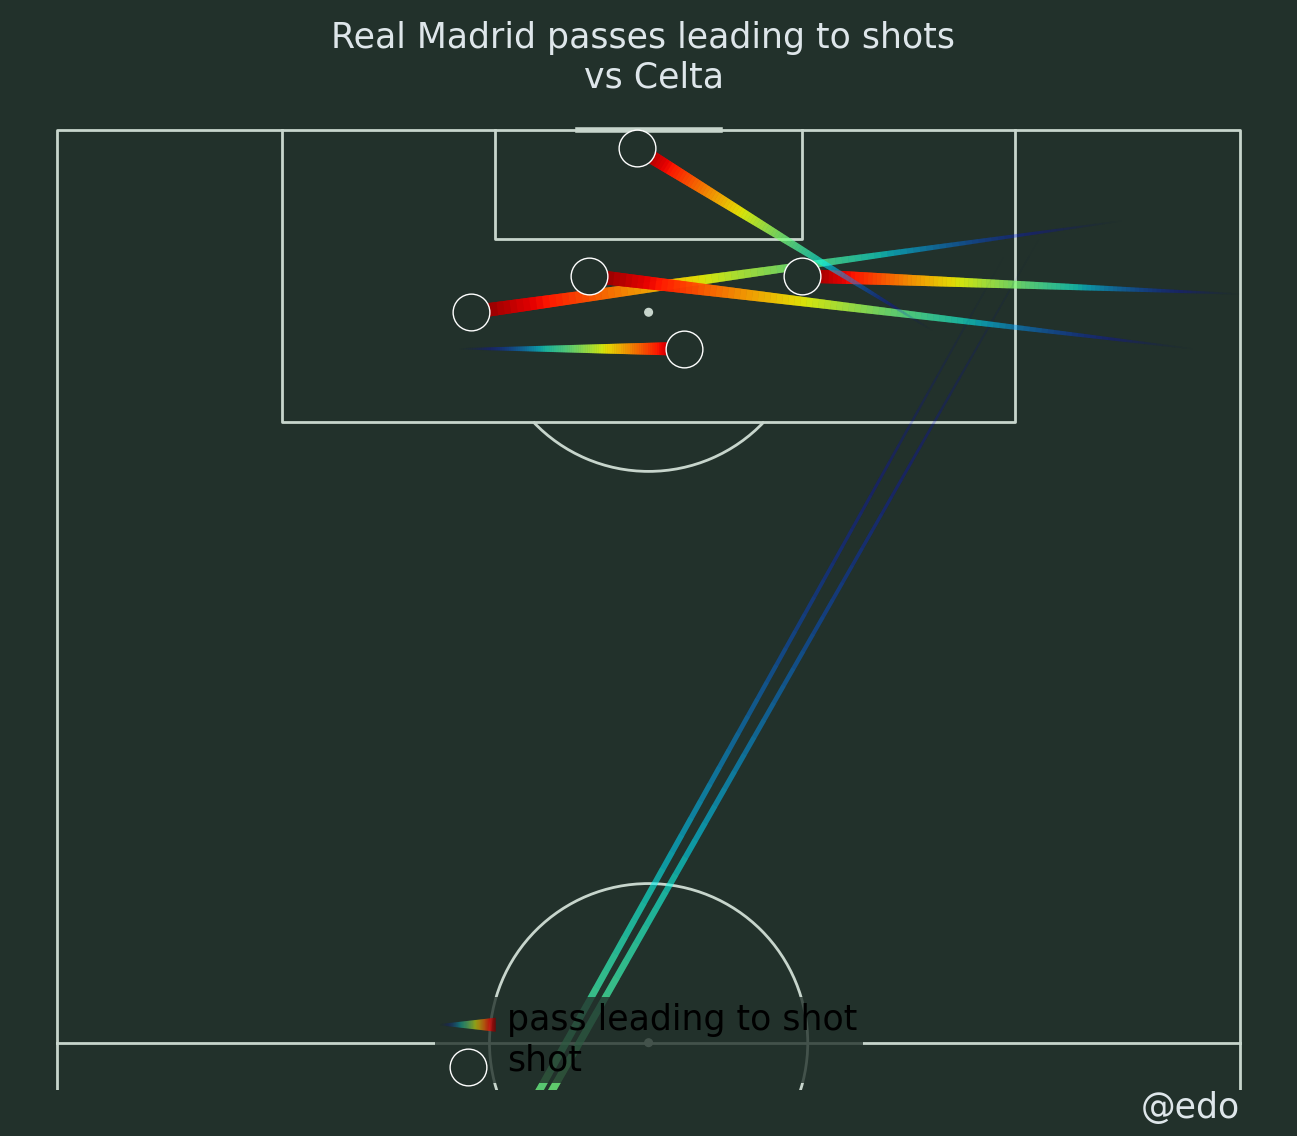

In [ ]:
fig, axs = plot_passes_leading_to_shots_grid(
    df_pass,
    "Real Madrid",
    "Celta",
    is_goal_col="shot_is_goal",   # o mask_goal=...
    pitch_coords="wyscout_100",
    endnote_text="@edo",
    
)
plt.show()

In [158]:
def plot_crosses_same_pitch_as_pass_leading(
    df_cross: pd.DataFrame,
    title: str,
    *,
    # stesso header dei tiri
    left_logo_path: str = "images/sport_data_campus.png",
    team_img_source=None,
    player_img_source=None,
    header_center_y: float = 0.915,
    header_title_color: str = "#A8A9AD",
    figheight: float = 12,
    legend_ncol: int = 3,
    line_lw: float = 6,
    line_cmap: str = "jet",
) -> tuple[plt.Figure, dict]:
    """
    Mezzo campo identico a plot_passes_leading_to_shots_grid (grid mplsoccer).
    Header = solo add_header_branding(...) come per lo shot map.
    """
    d = df_cross.copy()
    for c in ["location_x", "location_y", "pass_end_x", "pass_end_y"]:
        if c in d.columns:
            d[c] = pd.to_numeric(d[c], errors="coerce")

    x1 = d["pass_end_x"].fillna(0.0)
    y1 = d["pass_end_y"].fillna(0.0)
    blocked = (x1 == 0) & (y1 == 0)

    pitch = VerticalPitch(
        pitch_type="wyscout", pitch_length=100, pitch_width=100,
        half=True, pad_bottom=0.5, goal_type="box", goal_alpha=0.8
    )

    fig, ax_pitch = pitch.draw(figsize=(12, 10))

    

    # Header identico ai tiri (logo + titolo + 1/2 img a destra)
    add_header_branding(
        fig,
        title=title,
        left_logo_path=left_logo_path,
        team_img_source=team_img_source,
        player_img_source=player_img_source,
    )

   
    d_ok = d[~blocked].dropna(subset=["location_x", "location_y", "pass_end_x", "pass_end_y"])
    if not d_ok.empty:
        pitch.lines(
            d_ok["location_x"],
            d_ok["location_y"],
            d_ok["pass_end_x"],
            d_ok["pass_end_y"],
            lw=line_lw,
            transparent=True,
            comet=True,
            cmap=line_cmap,
            label="cross",
            ax=ax_pitch,
        )

    d_blk = d[blocked].dropna(subset=["location_x", "location_y"])
    if not d_blk.empty:
        pitch.scatter(
            d_blk["location_x"],
            d_blk["location_y"],
            marker="x",
            s=280,
            linewidths=2.5,
            c="#ff6b6b",
            edgecolors="white",
            zorder=5,
            label="cross blocked (0,0)",
            ax=ax_pitch,
        )

    leg = ax_pitch.legend(
        
        loc="lower center",
        ncol=legend_ncol,
        handlelength=4,
    )
   

    return fig, axs

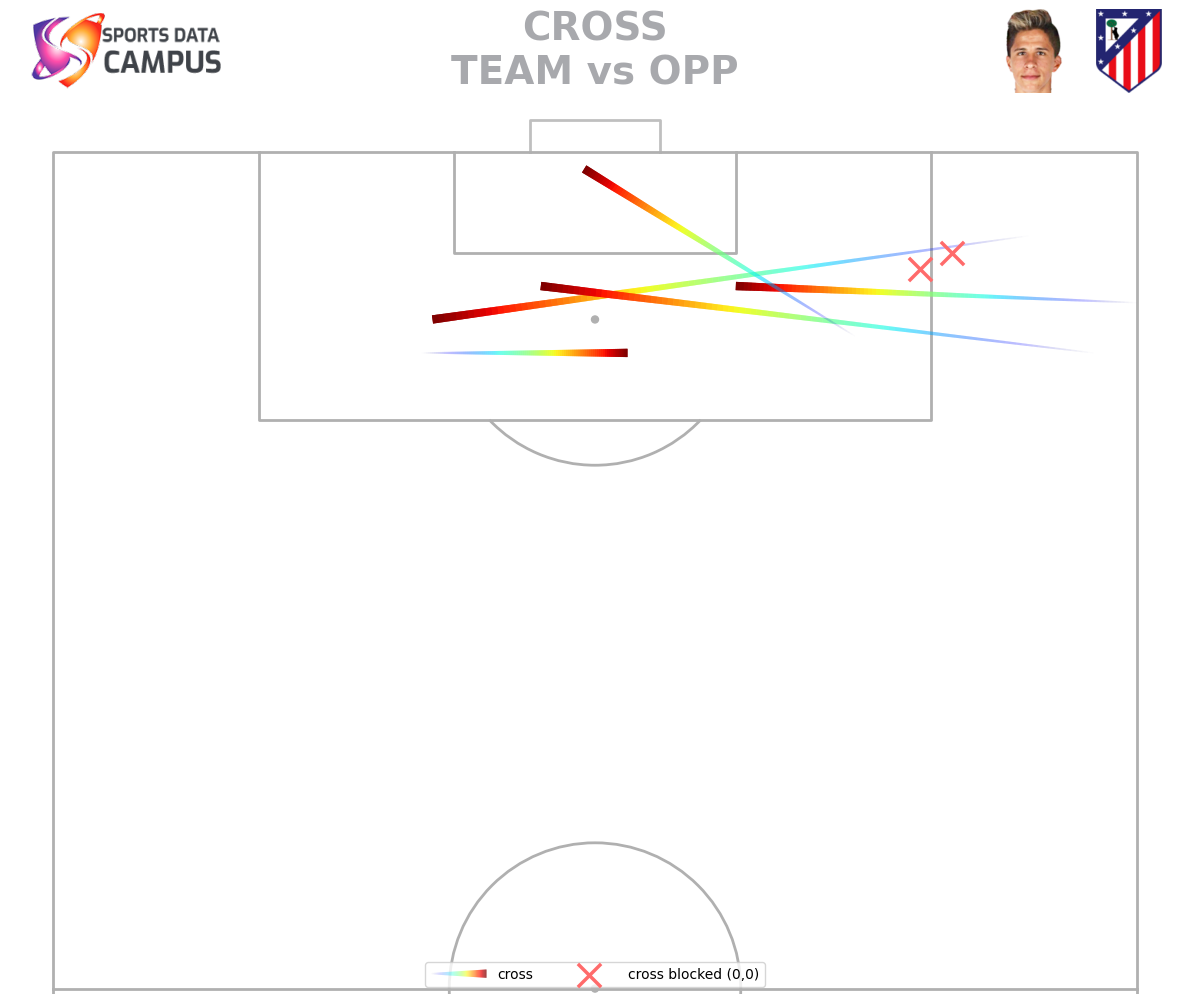

In [159]:

fig, axs = plot_crosses_same_pitch_as_pass_leading(
    df_pass,
    "CROSS\nTEAM vs OPP",
    player_img_source=out["player_image_data_url"],
    team_img_source=out["team_image_data_url"],  # o None
    legend_ncol=3,
)
plt.show()
plt.show()